## 0. Tiền xử lý dữ liệu

Import các thư viện cần thiết để tính toán các chỉ số độ ẩm và thực hiện các phân tích tương quan nhiệt - ẩm.

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
folder_path = r'D:\clone\merged'

Xây dựng các hàm xử lý dữ liệu độ ẩm. Trong phần này, chúng ta tập trung vào các đại lượng vật lý đặc trưng cho lượng hơi nước trong không khí:
- **T2m (Air Temperature)**: Nhiệt độ không khí tại độ cao 2m.
- **Td (Dewpoint Temperature)**: Nhiệt độ điểm sương - mức nhiệt độ mà tại đó không khí bị bão hòa hơi nước.
- **DPD (Dewpoint Depression)**: Chênh lệch điểm sương ($T - T_d$). DPD càng nhỏ, không khí càng gần trạng thái bão hòa (độ ẩm cao).
- **RH (Relative Humidity)**: Độ ẩm tương đối (%), được tính toán bằng công thức xấp xỉ Magnus dựa trên nhiệt độ và điểm sương.

In [2]:
def approx_rh(t, td):
    return 100 * np.exp((17.625 * td) / (243.04 + td)) / np.exp((17.625 * t) / (243.04 + t))

def load_and_process_humidity(d2m_file, t2m_file):
    def preprocess(ds):
        if 'valid_time' in ds.coords: ds = ds.rename({'valid_time': 'time'})
        if 'expver' in ds.dims: ds = ds.mean(dim='expver')
        return ds.sortby('time')

    ds_d2m = preprocess(xr.open_dataset(os.path.join(folder_path, d2m_file)))
    var_d2m = list(ds_d2m.data_vars)[0]
    d2m_hourly = (ds_d2m[var_d2m] - 273.15).mean(dim=['latitude', 'longitude']).compute()
    
    ds_t2m = preprocess(xr.open_dataset(os.path.join(folder_path, t2m_file)))
    var_t2m = list(ds_t2m.data_vars)[0]
    t2m_hourly = (ds_t2m[var_t2m] - 273.15).mean(dim=['latitude', 'longitude']).compute()

    df_hourly = pd.DataFrame({'d2m': d2m_hourly.values}, index=d2m_hourly.time.values)

    df_daily = pd.DataFrame()
    df_daily['d2m'] = d2m_hourly.resample(time='1D').mean().values
    df_daily['t2m'] = t2m_hourly.resample(time='1D').mean().values
    df_daily.index = d2m_hourly.resample(time='1D').mean().time.values

    df_daily['dpd'] = df_daily['t2m'] - df_daily['d2m']
    df_daily['rh'] = approx_rh(df_daily['t2m'], df_daily['d2m'])

    df_monthly = df_daily.resample('ME').mean()
    df_yearly = df_daily.resample('YS').mean()

    climatology = df_monthly.groupby(df_monthly.index.month).mean()

    df_monthly['month'] = df_monthly.index.month
    df_monthly['year'] = df_monthly.index.year

    df_anomaly = pd.DataFrame(index=df_monthly.index)
    df_anomaly['year'] = df_monthly['year']
    df_anomaly['month'] = df_monthly['month']
    df_anomaly['d2m'] = df_monthly['d2m'] - df_monthly['month'].map(climatology['d2m'])

    ds_d2m.close()
    ds_t2m.close()
    gc.collect()

    return df_daily, df_monthly, df_yearly, df_anomaly, climatology, df_hourly

Thực thi nạp dữ liệu và tính toán các đặc trưng độ ẩm khí quyển.

In [3]:
d2m_file = '2m_dewpoint_temperature_merged.nc'
t2m_file = '2m_temperature_merged.nc'

df_daily, df_monthly, df_yearly, df_anomaly, climatology, df_hourly = load_and_process_humidity(d2m_file, t2m_file)
df_daily.head()

,d2m,t2m,dpd,rh
1980-01-01,18.340076,23.688828,5.348751,71.990410
1980-01-02,17.829498,23.533554,5.704056,70.373138
1980-01-03,17.615753,23.554111,5.938358,69.345947
1980-01-04,16.844023,22.988262,6.144239,68.339203
1980-01-05,15.690338,21.940742,6.250404,67.669876


## 1. Khí hậu học theo mùa: Nhiệt độ điểm sương vs Nhiệt độ không khí

Biểu đồ mô tả chu kỳ mùa của nền nhiệt độ và điểm sương. 
Khoảng cách giữa hai đường (`DPD`) phản ánh mức độ khô hạn hoặc ẩm ướt của không khí. Vào mùa mưa hoặc giai đoạn nồm ẩm, hai đường này sẽ tiến lại gần nhau. Ngược lại, vào các tháng khô hanh, khoảng cách này sẽ nới rộng đáng kể.

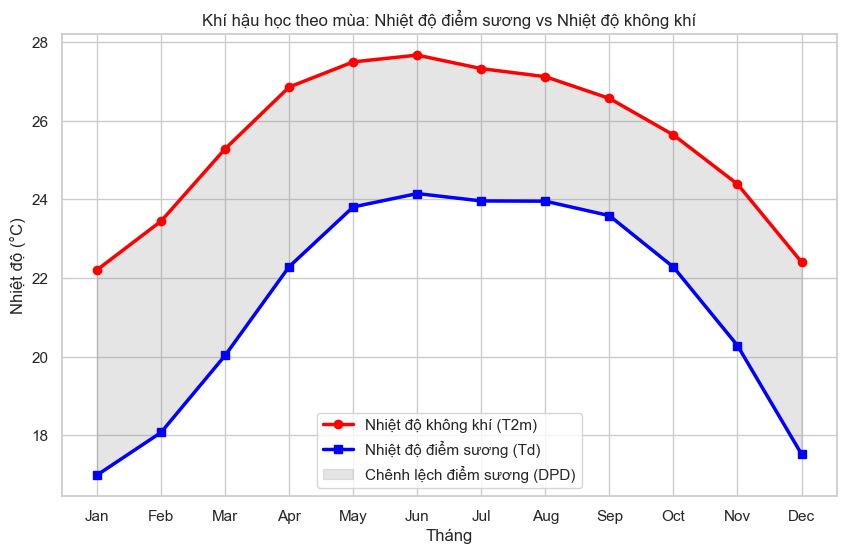

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(climatology.index, climatology['t2m'], marker='o', color='red', linewidth=2.5, label='Nhiệt độ không khí (T2m)')
plt.plot(climatology.index, climatology['d2m'], marker='s', color='blue', linewidth=2.5, label='Nhiệt độ điểm sương (Td)')
plt.fill_between(climatology.index, climatology['d2m'], climatology['t2m'], color='gray', alpha=0.2, label='Chênh lệch điểm sương (DPD)')
plt.title("Khí hậu học theo mùa: Nhiệt độ điểm sương vs Nhiệt độ không khí")
plt.xlabel("Tháng")
plt.ylabel("Nhiệt độ (°C)")
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.show()

## 2. Chu kỳ mùa và xu hướng của chênh lệch điểm sương (DPD)

Phân tích chỉ số $DPD$:
- **Bên trái**: Biến thiên $DPD$ theo tháng. Chỉ số này thường đạt cực tiểu vào mùa ẩm, cho thấy khả năng hình thành sương mù hoặc mây thấp cao.
- **Bên phải**: Xu hướng dài hạn của $DPD$. Nếu $DPD$ có xu hướng tăng, điều đó cho thấy không khí đang trở nên "khô" hơn so với khả năng chứa nước của nó (ngay cả khi lượng hơi nước có thể tăng).

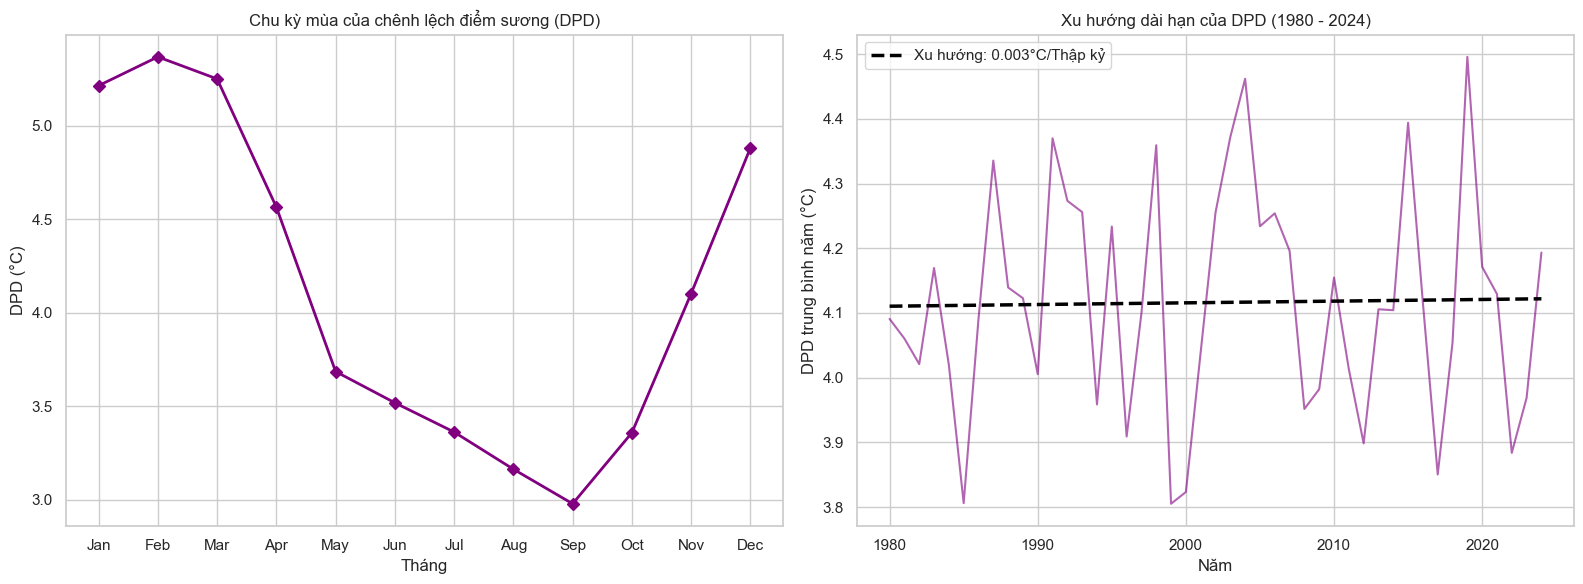

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(climatology.index, climatology['dpd'], marker='D', color='purple', linewidth=2)
ax1.set_title("Chu kỳ mùa của chênh lệch điểm sương (DPD)")
ax1.set_xlabel("Tháng")
ax1.set_ylabel("DPD (°C)")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

y_vals = df_yearly['dpd'].values
x_vals = df_yearly.index.year.values
slope, intercept, r_value, p_value, std_err = stats.linregress(x_vals, y_vals)
trend_line = intercept + slope * x_vals

ax2.plot(x_vals, y_vals, color='purple', alpha=0.6, linewidth=1.5)
ax2.plot(x_vals, trend_line, color='black', linestyle='--', linewidth=2.5, label=f"Xu hướng: {slope*10:0.3f}°C/Thập kỷ")
ax2.set_title("Xu hướng dài hạn của DPD (1980 - 2024)")
ax2.set_xlabel("Năm")
ax2.set_ylabel("DPD trung bình năm (°C)")
ax2.legend()

plt.tight_layout()
plt.show()

## 3. Xu hướng dài hạn của Nhiệt độ điểm sương (so sánh với T2m)

Biểu đồ này kiểm định giả thuyết về việc bầu khí quyển đang nóng lên và ẩm hơn đồng thời. Việc theo dõi song song xu hướng của `Td` và `T2m` giúp ta hiểu rõ hơn về tốc độ gia tăng hơi nước tuyệt đối so với tốc độ tăng nhiệt độ.

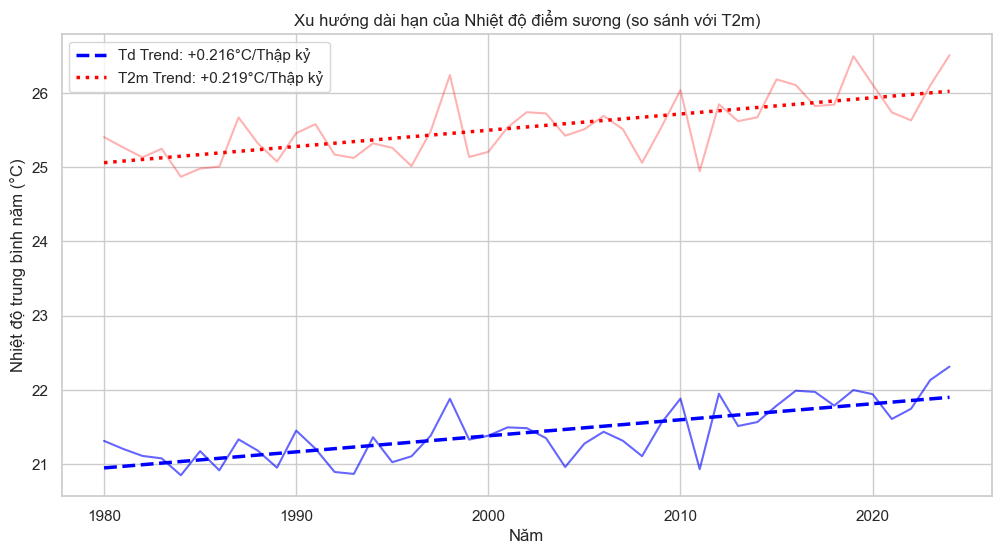

In [6]:
plt.figure(figsize=(12, 6))

y_vals = df_yearly['d2m'].values
x_vals = df_yearly.index.year.values
slope, intercept, _, _, _ = stats.linregress(x_vals, y_vals)
trend_line = intercept + slope * x_vals

plt.plot(x_vals, y_vals, color='blue', alpha=0.6, linewidth=1.5)
plt.plot(x_vals, trend_line, color='blue', linestyle='--', linewidth=2.5, label=f"Td Trend: +{slope*10:0.3f}°C/Thập kỷ")

y_vals_t = df_yearly['t2m'].values
slope_t, intercept_t, _, _, _ = stats.linregress(x_vals, y_vals_t)
trend_line_t = intercept_t + slope_t * x_vals

plt.plot(x_vals, y_vals_t, color='red', alpha=0.3, linewidth=1.5)
plt.plot(x_vals, trend_line_t, color='red', linestyle=':', linewidth=2.5, label=f"T2m Trend: +{slope_t*10:0.3f}°C/Thập kỷ")

plt.title("Xu hướng dài hạn của Nhiệt độ điểm sương (so sánh với T2m)")
plt.xlabel("Năm")
plt.ylabel("Nhiệt độ trung bình năm (°C)")
plt.legend()
plt.show()

## 4. Ma trận dị thường Nhiệt độ điểm sương

Heatmap thể hiện các giai đoạn bất thường về lượng hơi nước tuyệt đối trong không khí:
- **Màu nâu/vàng (Br)**: Dị thường âm, khí quyển khô hơn bình thường.
- **Màu xanh lá/xanh dương (BG)**: Dị thường dương, không khí chứa nhiều hơi nước hơn bình thường (dấu hiệu của các đợt nồm ẩm hoặc gió mùa mạnh xuất hiện nhiều hơn).

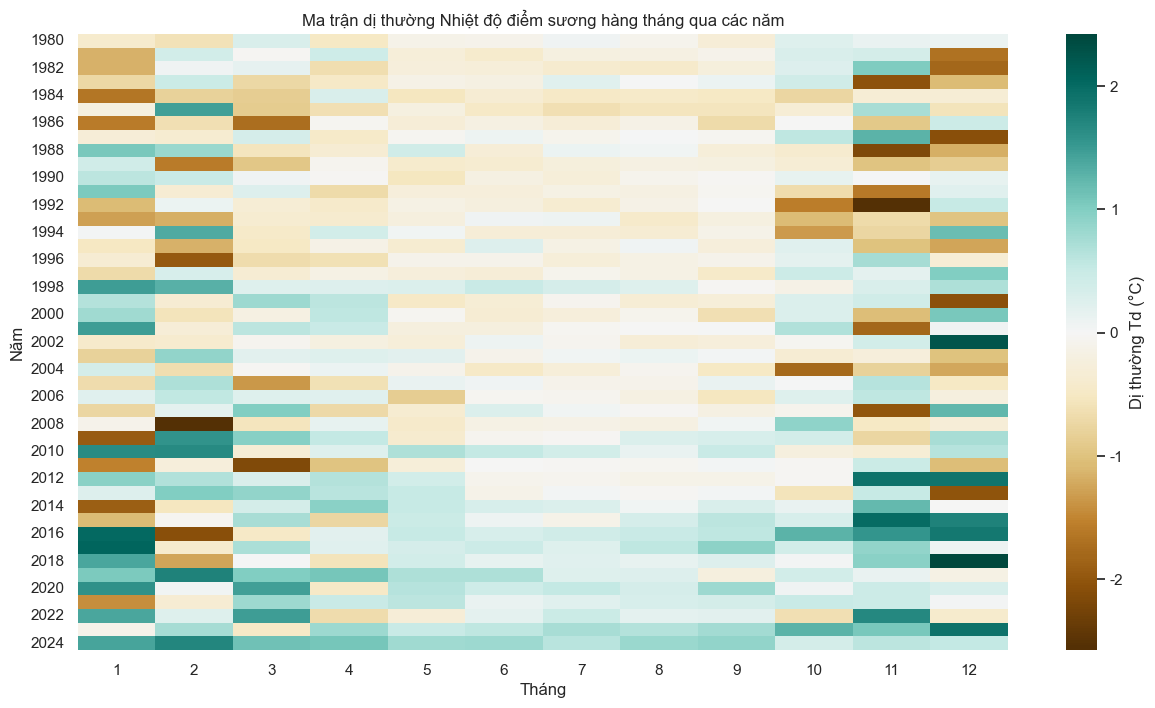

In [7]:
pivot_table = df_anomaly.pivot(index='year', columns='month', values='d2m')

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_table, cmap="BrBG", center=0, cbar_kws={'label': 'Dị thường Td (°C)'})
plt.title("Ma trận dị thường Nhiệt độ điểm sương hàng tháng qua các năm")
plt.xlabel("Tháng")
plt.ylabel("Năm")
plt.show()

## 5. Tương quan Nhiệt độ điểm sương và Nhiệt độ không khí

Biểu đồ Scatter plot thể hiện trạng thái nhiệt - ẩm của khu vực:
- **Đường nét đứt ($y=x$)**: Đại diện cho trạng thái bão hòa hoàn toàn (RH = 100%). Không có điểm dữ liệu nào có thể nằm trên đường này (về mặt vật lý $T_d \le T$).
- Các điểm càng nằm gần đường chéo càng thể hiện không khí ẩm và oi bức. Màu sắc theo tháng giúp nhận diện các khối khí khác nhau tràn qua khu vực nghiên cứu.

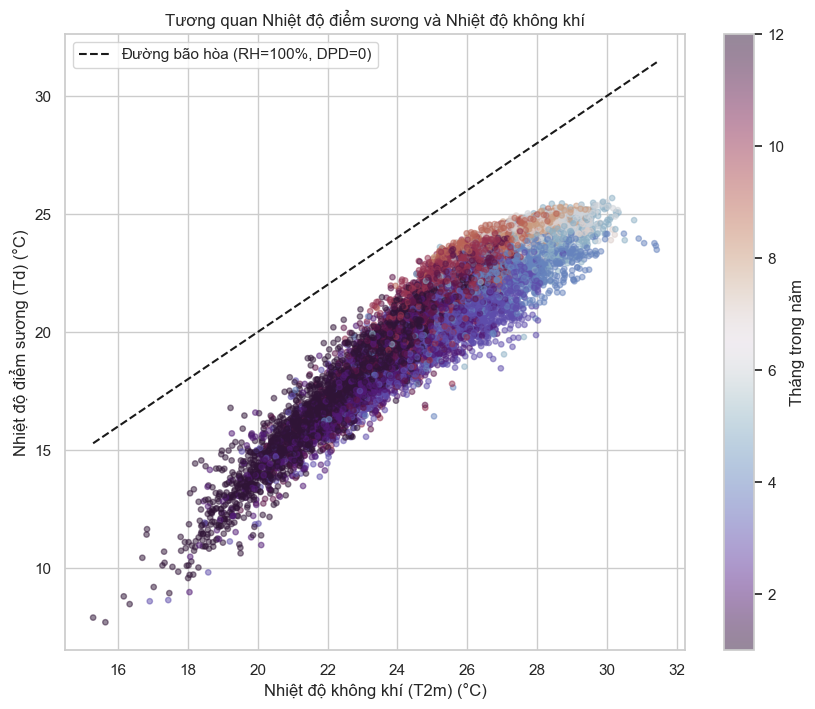

In [8]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(df_daily['t2m'], df_daily['d2m'], c=df_daily.index.month, cmap='twilight_shifted', alpha=0.5, s=15)

plt.plot([df_daily['t2m'].min(), df_daily['t2m'].max()], [df_daily['t2m'].min(), df_daily['t2m'].max()], 'k--', label='Đường bão hòa (RH=100%, DPD=0)')

plt.colorbar(scatter, label='Tháng trong năm')
plt.title("Tương quan Nhiệt độ điểm sương và Nhiệt độ không khí")
plt.xlabel("Nhiệt độ không khí (T2m) (°C)")
plt.ylabel("Nhiệt độ điểm sương (Td) (°C)")
plt.legend()
plt.show()

## 6. Tần suất số ngày độ ẩm cao cực đoan

Thống kê số ngày trong năm có độ ẩm tương đối ($RH$) trung bình vượt ngưỡng 85%. 
Đây là các giai đoạn "ẩm cực đoan", gây ảnh hưởng lớn đến sức khỏe con người, hoạt động nông nghiệp cũng như tạo điều kiện cho các mầm bệnh phát triển.

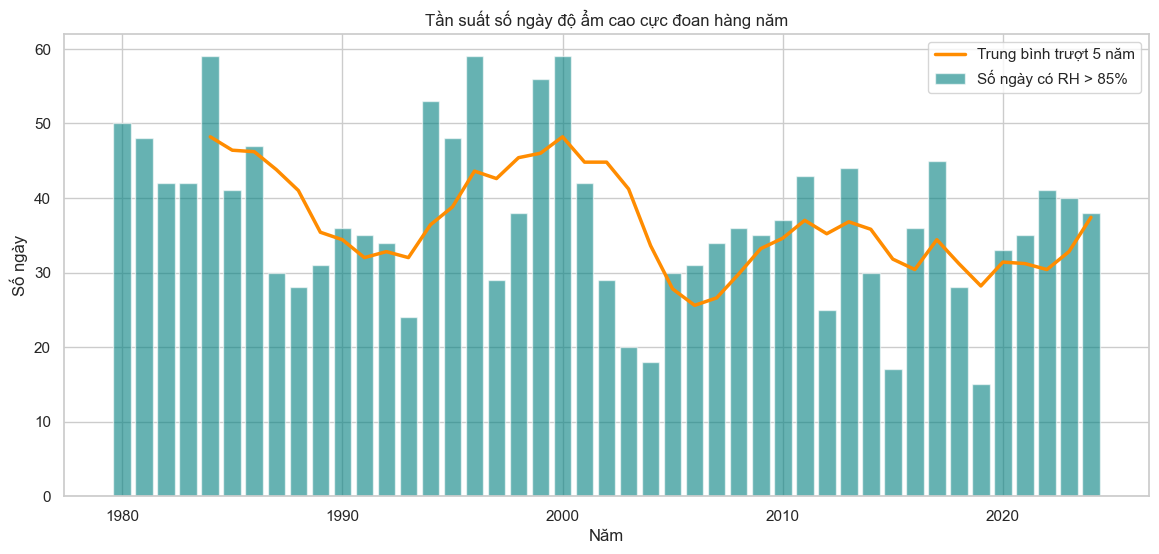

In [9]:
high_rh_days = (df_daily['rh'] > 85).resample('YS').sum()

plt.figure(figsize=(14, 6))
plt.bar(high_rh_days.index.year, high_rh_days.values, color='teal', alpha=0.6, label='Số ngày có RH > 85%')
plt.plot(high_rh_days.index.year, high_rh_days.rolling(5).mean(), color='darkorange', linewidth=2.5, label='Trung bình trượt 5 năm')

plt.title("Tần suất số ngày độ ẩm cao cực đoan hàng năm")
plt.ylabel("Số ngày")
plt.xlabel("Năm")
plt.legend()
plt.show()

## 7. Chu kỳ ngày đêm của Nhiệt độ điểm sương theo mùa

Phân tích biến trình giờ của điểm sương để thấy được sự thay đổi của hơi nước trong 24 giờ. 
Điểm sương thường có biến động nhỏ hơn nhiệt độ không khí trong ngày, nhưng sự thay đổi của nó phản ánh các quá trình bốc hơi bề mặt (evapotranspiration) vào ban ngày và quá trình ngưng tụ sương vào ban đêm.

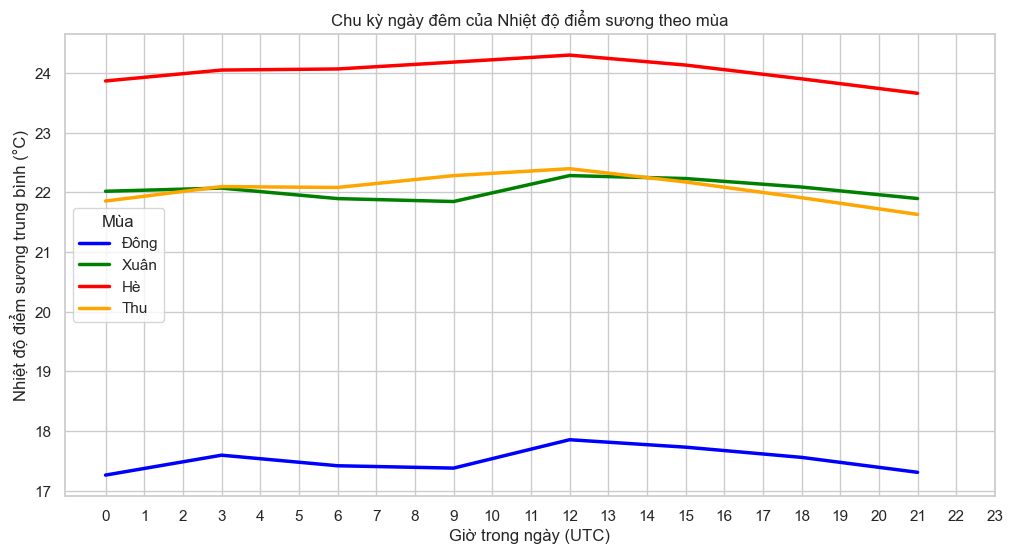

In [10]:
df_hourly['season'] = df_hourly.index.month.map({12:'DJF', 1:'DJF', 2:'DJF', 3:'MAM', 4:'MAM', 5:'MAM', 6:'JJA', 7:'JJA', 8:'JJA', 9:'SON', 10:'SON', 11:'SON'})
df_hourly['hour'] = df_hourly.index.hour

hourly_season = df_hourly.groupby(['season', 'hour'])['d2m'].mean().unstack(level=0)

plt.figure(figsize=(12, 6))
colors_season = {'DJF': 'blue', 'MAM': 'green', 'JJA': 'red', 'SON': 'orange'}

season_vi = {
    'DJF': 'Đông',
    'MAM': 'Xuân',
    'JJA': 'Hè',
    'SON': 'Thu'
}

for season in ['DJF', 'MAM', 'JJA', 'SON']:
    plt.plot(hourly_season.index, hourly_season[season], color=colors_season[season], linewidth=2.5, label=season_vi[season])

plt.title("Chu kỳ ngày đêm của Nhiệt độ điểm sương theo mùa")
plt.xlabel("Giờ trong ngày (UTC)")
plt.ylabel("Nhiệt độ điểm sương trung bình (°C)")
plt.xticks(range(0, 24))
plt.legend(title="Mùa")
plt.show()